# Forcing-input exploration: mlm_canopy / interception / planttype (debug/tl-convergence-isolation)

**Research/debug notebook — lives on branch `debug/tl-convergence-isolation`, not intended to be merged.**

Companion to `debug_mlm_canopy_convergence.ipynb`. That notebook isolates and replays
*individual* Picard-loop non-convergence timesteps. This notebook instead looks at
**forcing-input distributions across an entire month** (2022-06-01 to 2022-06-30,
FI-Ran clear-cut), split into timesteps where the Picard loop converged normally vs.
timesteps that ended up `'tolerable'` or `'switched_to_wma'` (see
`pyAPES/canopy/mlm_canopy.py`) — to see whether non-convergence is associated with
particular forcing conditions, not just particular hours.

Non-convergence is known (from `debug_mlm_canopy_convergence.ipynb`) to concentrate
at night. A naive converged-vs-non-converged comparison would therefore mostly just
reproduce day/night differences in forcing (radiation, temperature, ...). To control
for that, this notebook first finds which hours-of-day actually have non-convergent
timesteps, then compares converged vs. non-converged **forcing input distributions
restricted to those same hours** — e.g. if interception only fails at night, we
compare against *converged* nighttime inputs, not all converged inputs.

To regenerate the captured data this notebook reads:

```bash
rm -rf Examples/debug_captures/forcing_exploration
PYTHONPATH=. .venv/bin/python Examples/capture_forcing_exploration.py
```

This runs `PYAPES_FORCING_CAPTURE_DIR=Examples/debug_captures/forcing_exploration`
(set inside the script), which makes `CanopyModel.run()`
(`pyAPES/canopy/mlm_canopy.py`) record, for **every** timestep (not just
non-convergent ones -- see `pyAPES.utils.debug_capture.record_forcing`):

- `mlm_canopy_forcing_samples.pkl`: the raw meteorological + soil-state forcing
  `CanopyModel.run()` received for the timestep.
- `interception_forcing_samples.pkl`: the forcing dict passed into `Interception.run()`,
  captured at `iter_no==2` (i.e. after one full Picard iteration has already run).
- `planttype_forcing_samples.pkl`: the forcing dict passed into each `PlantType.run()`
  call, likewise captured at `iter_no==2`.

`iter_no==2` rather than `iter_no==1` is deliberate: at `iter_no==1`,
`Tleaf_prev`/`Tleaf_wet` and the scalar profiles are still the raw `_restore()` guess
(air temperature copied onto every layer, etc.), not values the Picard loop has
actually worked on -- capturing there would mostly show the warm-start guess rather
than forcing the loop actually converges around.

Each is a list of dicts with `timestamp`, `outcome`
(`'converged'` / `'tolerable'` / `'switched_to_wma'`), and the forcing keys for that
module (arrays kept as numpy arrays, nested dicts kept as nested dicts).

In [1]:
import os
import sys

# Jupyter runs this notebook's kernel with cwd = this file's own directory (Examples/),
# same convention as debug_mlm_canopy_convergence.ipynb.
assert os.path.basename(os.getcwd()) == 'Examples', (
    f"expected to run with cwd=Examples/, got {os.getcwd()!r} -- adjust paths below if not")
sys.path.insert(0, os.path.abspath('..'))  # repo root, so `import pyAPES` works

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CAPTURE_DIR = 'debug_captures/forcing_exploration'
TAGS = ['mlm_canopy', 'interception', 'planttype']

# validated status colors (good/critical) from the dataviz skill's default palette --
# 'converged' is the good outcome, 'tolerable'/'switched_to_wma' are lumped as 'non-converged'
COLOR_CONVERGED = '#0ca30c'
COLOR_NONCONVERGED = '#d03b3b'

## Load captures and flatten into per-variable, per-timestep tables

Profile/array-valued forcing entries (canopy or soil layers) are reduced to their
`nanmean` across the profile so they can be plotted as a single distribution; this
loses within-profile shape but is enough to see whether, say, mean canopy wind speed
or mean soil temperature differs between converged and non-converged timesteps.
Nested dicts (e.g. `PAR = {'direct', 'diffuse'}`, planttype `par/nir/lw` profiles)
are flattened into dotted column names (`PAR.direct`, `par.sunlit.incident`, ...).

In [2]:
def flatten_record(rec: dict, prefix: str = '') -> dict:
    # flatten one capture record into {column_name: scalar}, mean-reducing arrays
    out = {}
    for key, val in rec.items():
        name = f'{prefix}{key}'
        if isinstance(val, dict):
            out.update(flatten_record(val, prefix=f'{name}.'))
        elif isinstance(val, np.ndarray):
            out[name] = float(np.nanmean(val))
        else:
            out[name] = val
    return out


def load_forcing_table(tag: str) -> pd.DataFrame:
    fpath = os.path.join(CAPTURE_DIR, f'{tag}_forcing_samples.pkl')
    with open(fpath, 'rb') as fobj:
        records = pickle.load(fobj)
    df = pd.DataFrame([flatten_record(r) for r in records])
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['hour'] = df['timestamp'].dt.hour
    df['converged'] = df['outcome'] == 'converged'
    return df


tables = {tag: load_forcing_table(tag) for tag in TAGS}
for tag, df in tables.items():
    print(f"{tag}: {len(df)} timesteps, {len(df) - df['converged'].sum()} non-converged, "
          f"{df.shape[1]} columns")
tables['mlm_canopy'].head()

mlm_canopy: 1392 timesteps, 84 non-converged, 23 columns
interception: 1392 timesteps, 84 non-converged, 13 columns
planttype: 1392 timesteps, 84 non-converged, 31 columns


,timestamp,outcome,wind_speed,friction_velocity,air_temperature,precipitation,h2o,co2,PAR.direct,PAR.diffuse,...,air_pressure,zenith_angle,soil_temperature,soil_water_potential,soil_volumetric_water,soil_volumetric_ice,soil_volumetric_air,soil_pond_storage,hour,converged
0,2022-06-01 00:00:00,converged,2.361,0.387,8.805,0.0,0.010859,390.0,-0.0,-0.278,...,99184.5,1.646,-0.145222,-1.395455,0.283117,0.201709,0.411037,0.0,0,True
1,2022-06-01 00:30:00,converged,2.121,0.397,8.723,0.0,0.010785,390.0,-0.0,-0.177,...,99237.1,1.617,-0.031509,-1.395446,0.283119,0.201708,0.411037,0.0,0,True
2,2022-06-01 01:00:00,converged,2.097,0.354,8.649,0.0,0.010714,390.0,0.0,0.282,...,99277.8,1.582,0.029522,-1.395438,0.283121,0.201706,0.411037,0.0,1,True
3,2022-06-01 01:30:00,converged,2.399,0.384,8.589,0.0,0.010647,390.0,0.0,1.042,...,99294.9,1.541,0.075901,-1.395430,0.283124,0.201704,0.411036,0.0,1,True
4,2022-06-01 02:00:00,converged,2.348,0.374,8.499,0.0,0.010544,390.0,0.0,2.663,...,99322.9,1.494,0.114981,-1.395421,0.283126,0.201701,0.411036,0.0,2,True


## When does non-convergence happen? (time-of-day pattern)

Non-convergence rate by hour-of-day, over the full month. `mlm_canopy`,
`interception` and `planttype` share the same `outcome` per timestep (it is a
property of the whole Picard loop, recorded identically into all three tables), so
one hourly-rate plot covers all three modules.

Hours with >=1 non-convergent timestep: [0, 1, 19, 20, 21, 22, 23]


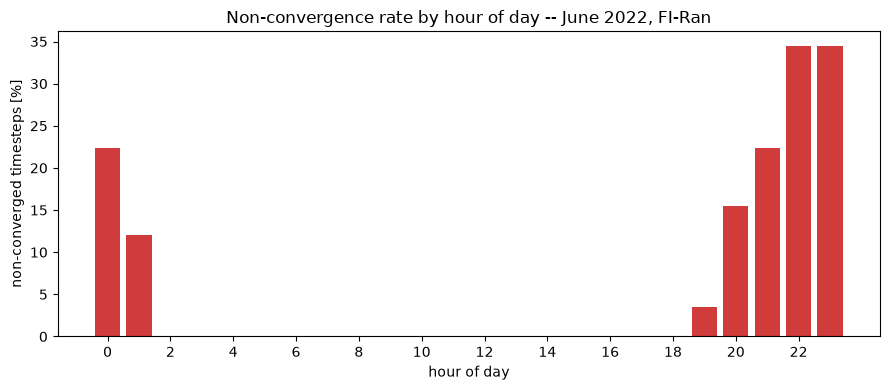

In [3]:
hourly = (
    tables['mlm_canopy']
    .groupby('hour')['converged']
    .agg(n='size', n_converged='sum')
)
hourly['n_nonconverged'] = hourly['n'] - hourly['n_converged']
hourly['nonconverged_rate'] = hourly['n_nonconverged'] / hourly['n']

# hours with at least one non-convergent timestep this month -- used below to
# restrict the converged/non-converged comparison to matching times of day
PROBLEM_HOURS = sorted(hourly.index[hourly['n_nonconverged'] > 0].tolist())
print('Hours with >=1 non-convergent timestep:', PROBLEM_HOURS)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(hourly.index, hourly['nonconverged_rate'] * 100, color=COLOR_NONCONVERGED)
ax.set_xlabel('hour of day')
ax.set_ylabel('non-converged timesteps [%]')
ax.set_xticks(range(0, 24, 2))
ax.set_title('Non-convergence rate by hour of day -- June 2022, FI-Ran')
plt.tight_layout()
plt.show()

## Forcing input distributions: converged vs. non-converged, matched by hour-of-day

For each module's forcing table, restrict to `PROBLEM_HOURS` (the hours identified
above as actually containing non-convergent timesteps) and compare the distribution
of each forcing variable between converged and non-converged timesteps **within
those same hours** -- so a difference in the plot reflects the forcing itself, not
just a day/night mix-up.

In [4]:
def plot_distribution_grid(df: pd.DataFrame, variables: list, title: str, ncols: int = 4, bins: int = 25):
    sub = df[df['hour'].isin(PROBLEM_HOURS)]
    converged = sub[sub['converged']]
    nonconverged = sub[~sub['converged']]
    print(f"{title}: comparing {len(converged)} converged vs {len(nonconverged)} non-converged "
          f"timesteps restricted to hours {PROBLEM_HOURS}")

    nrows = int(np.ceil(len(variables) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)

    for i, var in enumerate(variables):
        ax = axes[i // ncols][i % ncols]
        if var not in sub.columns:
            ax.set_visible(False)
            continue
        cvals = converged[var].dropna()
        nvals = nonconverged[var].dropna()
        edges = np.histogram_bin_edges(pd.concat([cvals, nvals]), bins=bins)
        ax.hist(cvals, bins=edges, density=True, alpha=0.55, color=COLOR_CONVERGED, label='converged')
        ax.hist(nvals, bins=edges, density=True, alpha=0.55, color=COLOR_NONCONVERGED, label='non-converged')
        ax.set_title(var, fontsize=9)
        ax.tick_params(labelsize=7)

    for j in range(len(variables), nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize=9)
    fig.suptitle(f'{title} -- forcing distributions restricted to hours {PROBLEM_HOURS}', y=1.02)
    plt.tight_layout()
    plt.show()

### mlm_canopy forcing (raw meteorology + soil state entering `CanopyModel.run()`)

mlm_canopy: comparing 322 converged vs 84 non-converged timesteps restricted to hours [0, 1, 19, 20, 21, 22, 23]


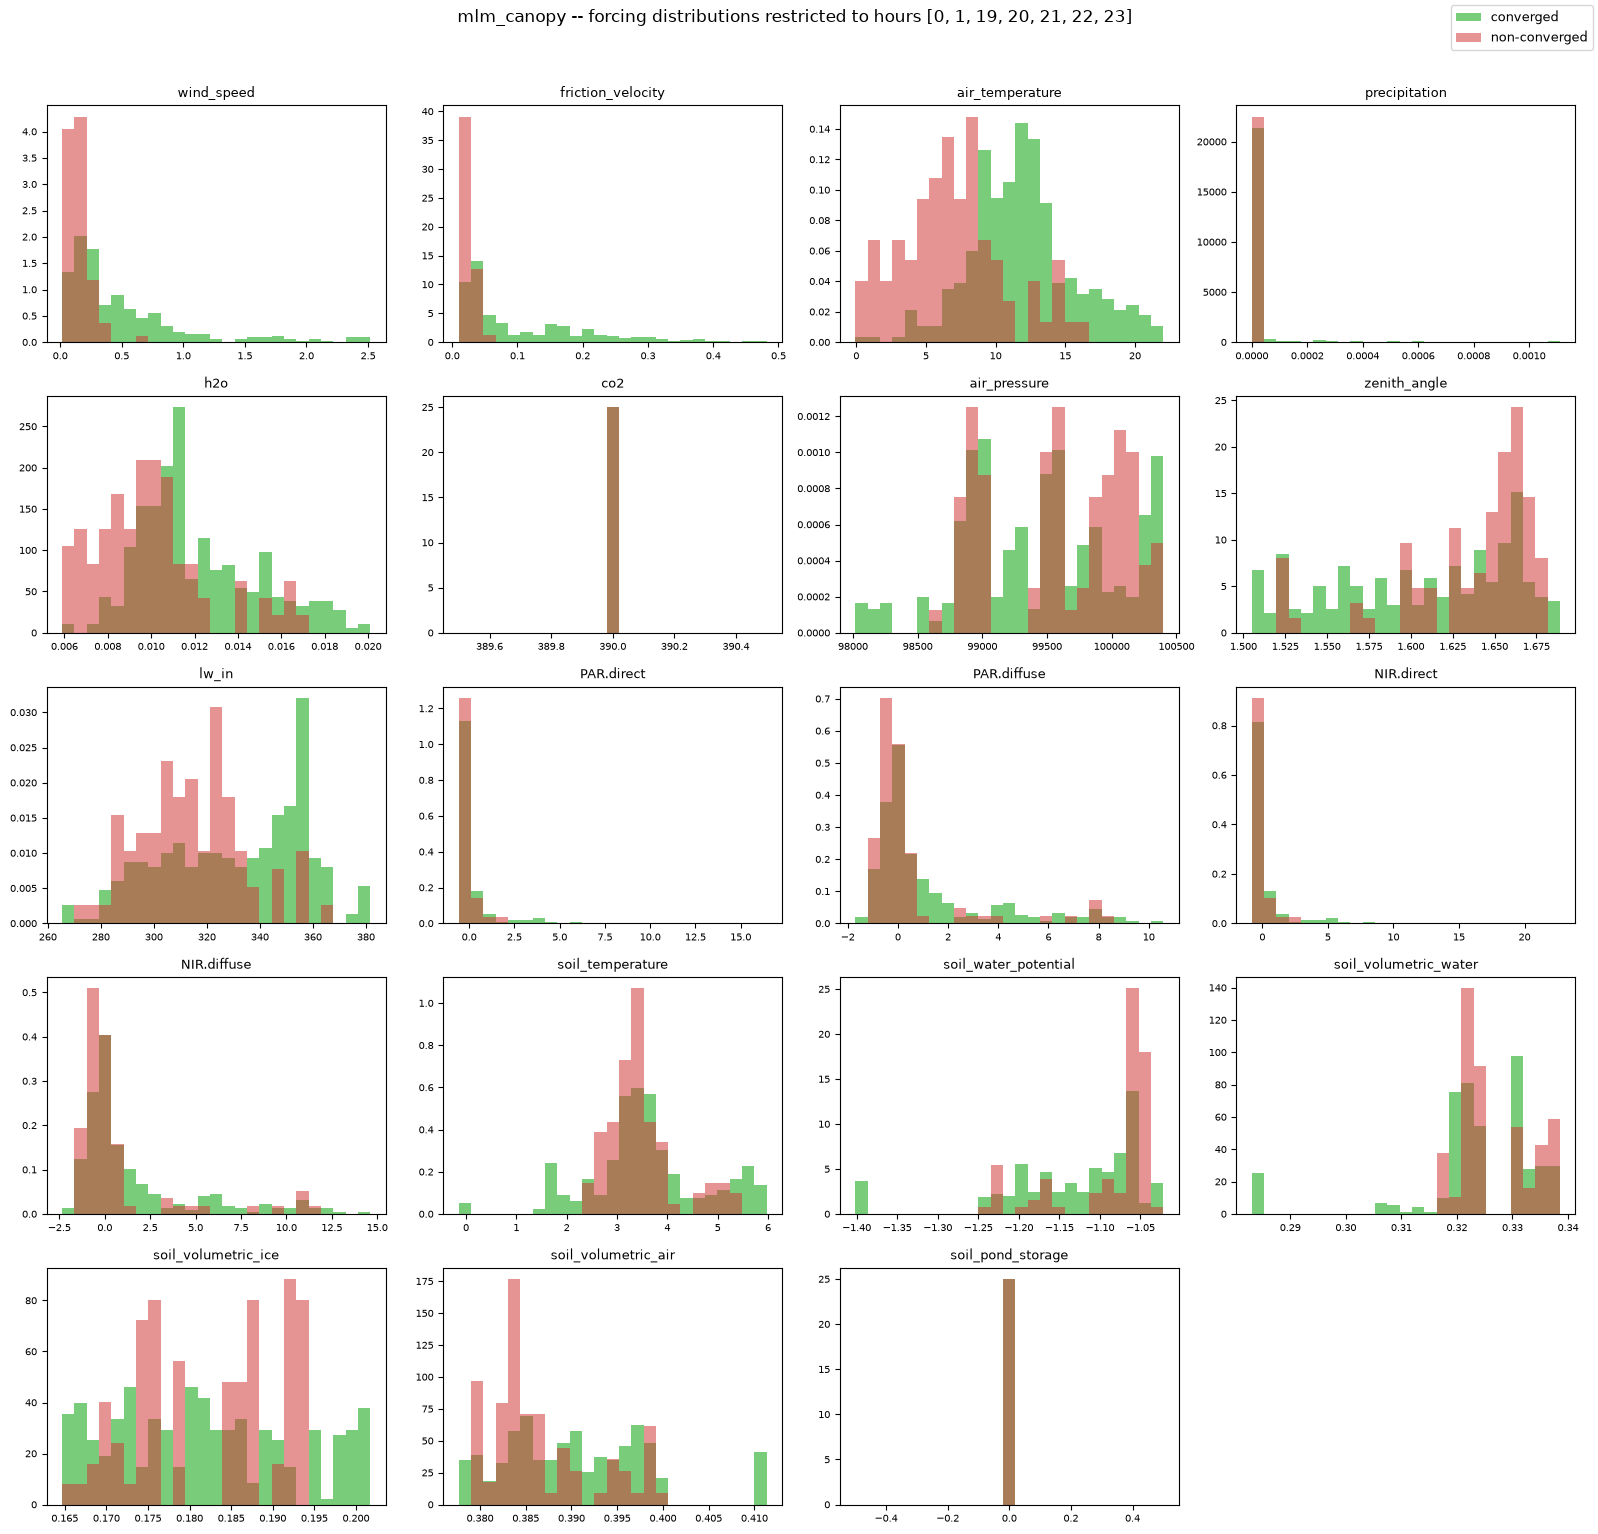

In [5]:
mlm_canopy_vars = [
    'wind_speed', 'friction_velocity', 'air_temperature', 'precipitation', 'h2o', 'co2',
    'air_pressure', 'zenith_angle', 'lw_in', 'PAR.direct', 'PAR.diffuse', 'NIR.direct', 'NIR.diffuse',
    'soil_temperature', 'soil_water_potential', 'soil_volumetric_water',
    'soil_volumetric_ice', 'soil_volumetric_air', 'soil_pond_storage',
]
plot_distribution_grid(tables['mlm_canopy'], mlm_canopy_vars, 'mlm_canopy')

### interception forcing (captured at iter_no==2, canopy-layer profiles mean-reduced)

interception: comparing 322 converged vs 84 non-converged timesteps restricted to hours [0, 1, 19, 20, 21, 22, 23]


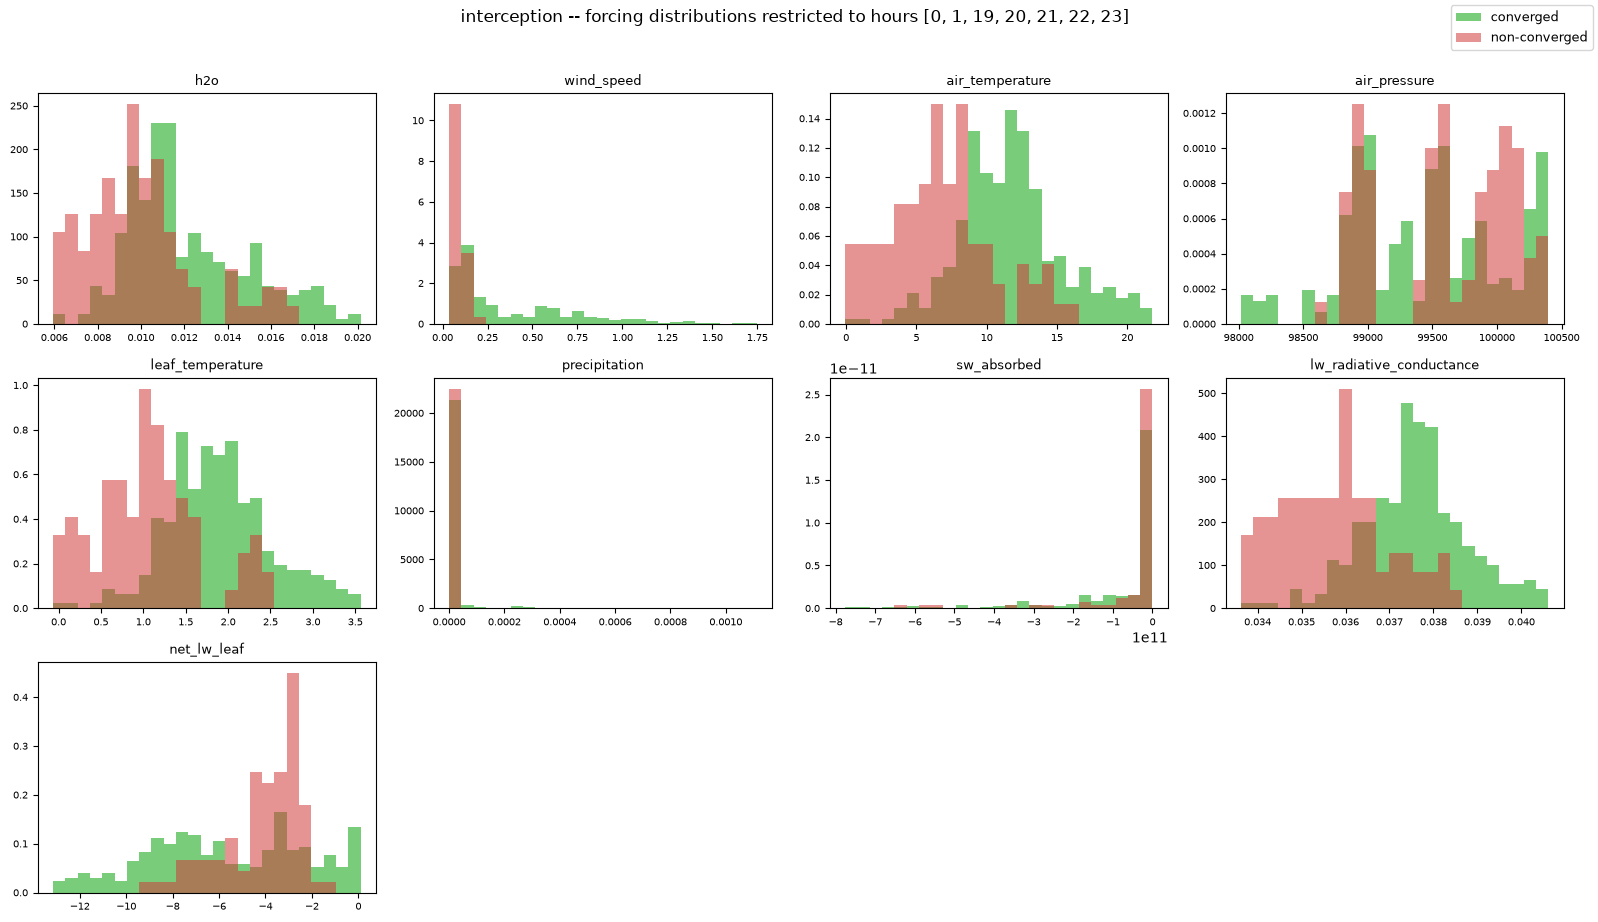

In [6]:
interception_vars = [
    'h2o', 'wind_speed', 'air_temperature', 'air_pressure', 'leaf_temperature',
    'precipitation', 'sw_absorbed', 'lw_radiative_conductance', 'net_lw_leaf',
]
plot_distribution_grid(tables['interception'], interception_vars, 'interception')

### planttype forcing (captured at iter_no==2, canopy-layer profiles mean-reduced)

planttype: comparing 322 converged vs 84 non-converged timesteps restricted to hours [0, 1, 19, 20, 21, 22, 23]


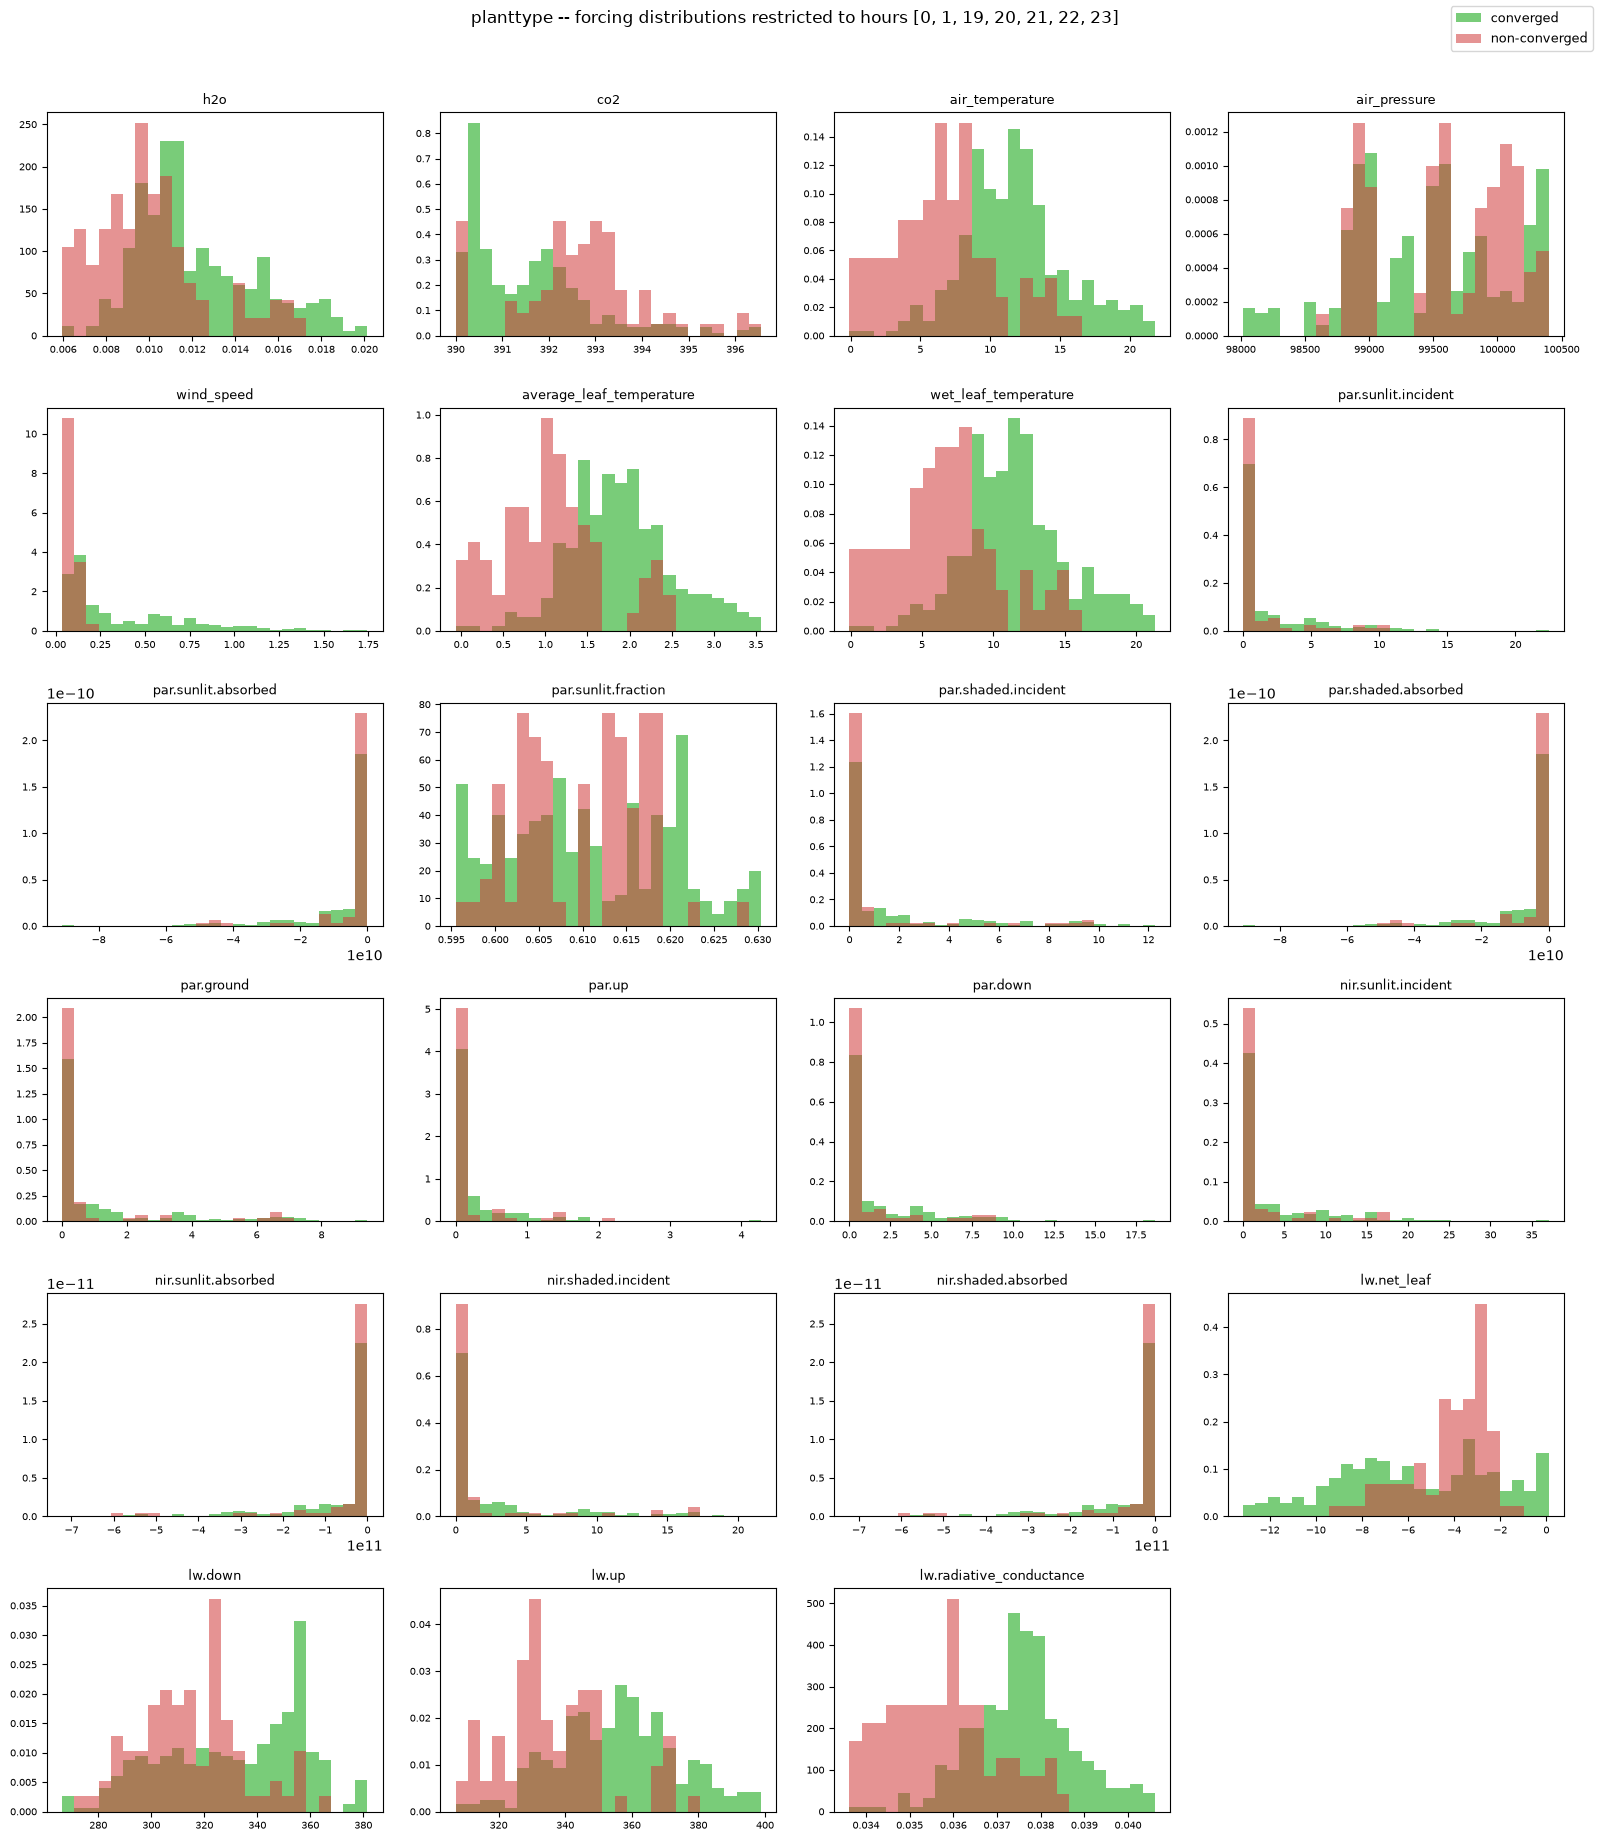

In [7]:
planttype_vars = [
    'h2o', 'co2', 'air_temperature', 'air_pressure', 'wind_speed',
    'average_leaf_temperature', 'wet_leaf_temperature',
    'par.sunlit.incident', 'par.sunlit.absorbed', 'par.sunlit.fraction',
    'par.shaded.incident', 'par.shaded.absorbed', 'par.ground', 'par.up', 'par.down',
    'nir.sunlit.incident', 'nir.sunlit.absorbed', 'nir.shaded.incident', 'nir.shaded.absorbed',
    'lw.net_leaf', 'lw.down', 'lw.up', 'lw.radiative_conductance',
]
plot_distribution_grid(tables['planttype'], planttype_vars, 'planttype')

## Notes / next steps

- Variables above where the converged/non-converged histograms clearly separate
  (even restricted to the same problem hours) are candidate drivers of the
  Picard-loop non-convergence and worth digging into further with
  `debug_mlm_canopy_convergence.ipynb`'s per-snapshot trajectory tools.
- The array-valued profiles were collapsed to their mean here; if a variable looks
  like a promising driver, re-plot it un-reduced (e.g. per canopy layer, or just the
  top/bottom of profile) since a mean can hide a localized layer effect.
- `PROBLEM_HOURS` and the `outcome` split come from a single month (June 2022); rerun
  `capture_forcing_exploration.py` over a different window to check robustness.